In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Chargement des données à partir d'un fichier CSV
data = pd.read_csv("kaggle_Interests_group.csv")
print(data.head()) 
print(data.info())

# Transférer les NaN en 0
data = data.fillna(0)

# Calcul du nombre de groupes distincts
nombre_de_groupes = data['group'].nunique()

# Calcul des occurrences de chaque groupe
occurrences_groupes = data['group'].value_counts()

# Calcul du nombre de personnes intéressées par chaque "interest"
somme_interets = data.iloc[:, 2:].sum()

# Création d'une structure pour stocker les groupes intéressés par chaque intérêt
groupes_par_interet = {
    col: data[data[col] == 1]['group'].value_counts().to_dict() 
    for col in data.columns[2:]
}

# Création du DataFrame final
resultats = pd.DataFrame({
    'Nombre de personnes intéressées': somme_interets,
    'Groupes intéressés': pd.Series(groupes_par_interet)
})

print(f"Nombre de groupes distincts: {nombre_de_groupes}")
print("Occurrences de chaque groupe:")
print(occurrences_groupes)
print("\nNombre de personnes intéressées par chaque intérêt:")
print(resultats['Nombre de personnes intéressées'])
print("\nGroupes intéressés par chaque intérêt:")
print(resultats['Groupes intéressés'])


  group  grand_tot_interests  interest1  interest2  interest3  interest4  \
0     C                   17        NaN        NaN        NaN        NaN   
1     C                   43        1.0        NaN        NaN        NaN   
2     C                   27        NaN        NaN        NaN        NaN   
3     C                   34        NaN        NaN        NaN        NaN   
4     C                   36        NaN        NaN        NaN        NaN   

   interest5  interest6  interest7  interest8  ...  interest208  interest209  \
0        NaN        NaN        NaN        NaN  ...          NaN          NaN   
1        1.0        NaN        NaN        NaN  ...          NaN          NaN   
2        NaN        NaN        NaN        NaN  ...          NaN          NaN   
3        NaN        NaN        NaN        NaN  ...          NaN          NaN   
4        1.0        NaN        NaN        NaN  ...          NaN          NaN   

   interest210  interest211  interest212  interest213  interes

In [ ]:
############# Visualisation 

/tmp/ipykernel_14290/3305675663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='group', palette='viridis')


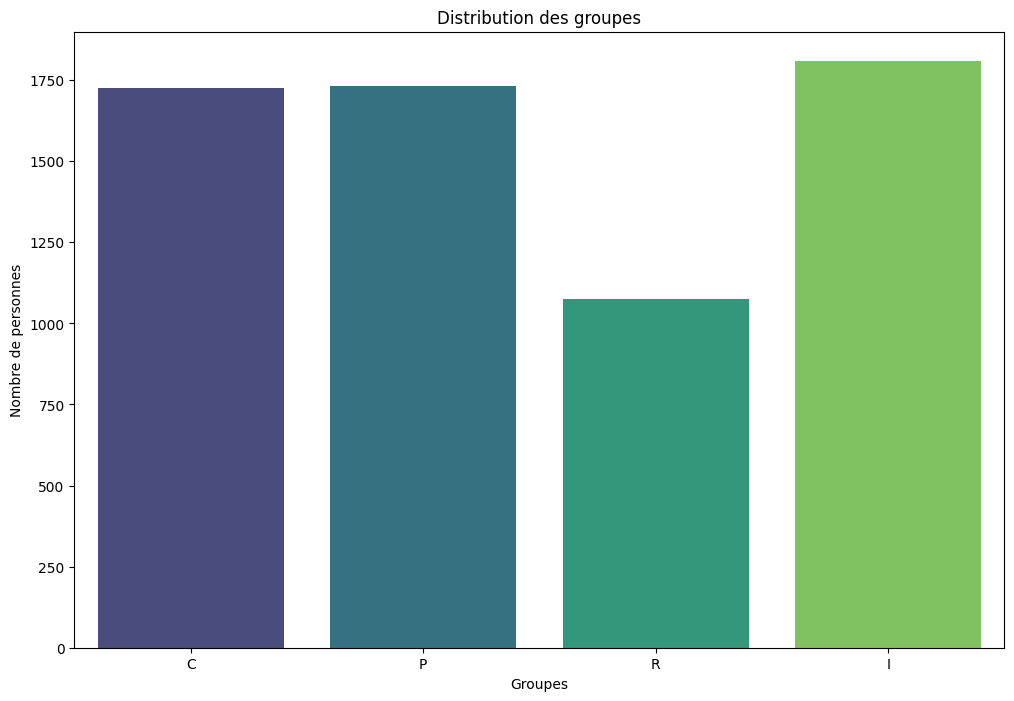

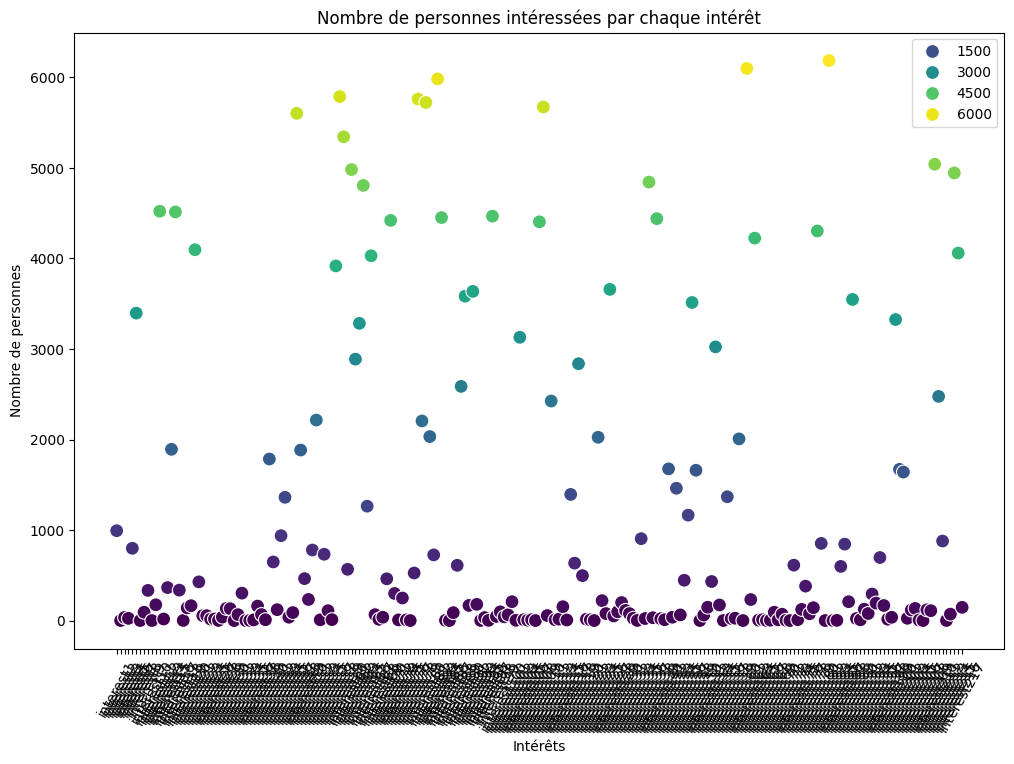

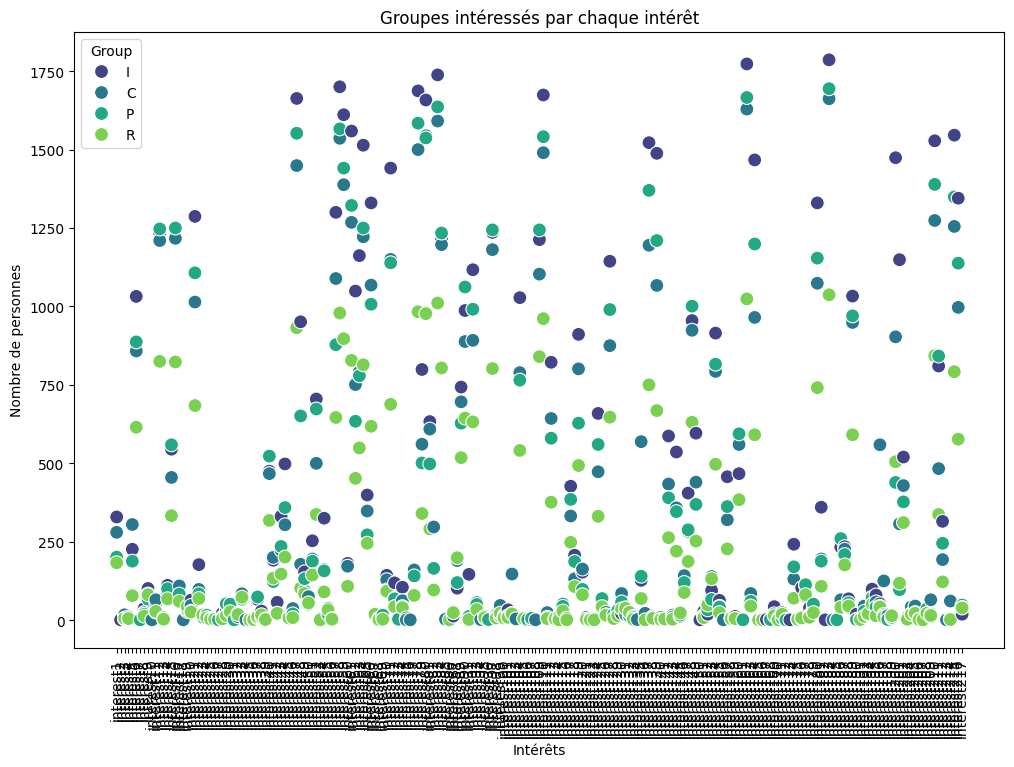

In [22]:
# Visualisation des résultats

# 1. Distribution des groupes par intérêt
plt.figure(figsize=(12, 8))
sns.countplot(data=data, x='group', palette='viridis')
plt.title('Distribution des groupes')
plt.xlabel('Groupes')
plt.ylabel('Nombre de personnes')
plt.show()

# 2. Nuage de points pour le nombre de personnes intéressées par chaque intérêt
plt.figure(figsize=(12, 8))
sns.scatterplot(x=somme_interets.index, y=somme_interets.values, hue=somme_interets.values, palette='viridis', s=100)
plt.title('Nombre de personnes intéressées par chaque intérêt')
plt.xlabel('Intérêts')
plt.ylabel('Nombre de personnes')
plt.xticks(rotation=60)  # Rotation des étiquettes pour meilleure lisibilité
plt.show()

# 3. Nuage de points pour les groupes intéressés par chaque intérêt
plt.figure(figsize=(12, 8))
group_interest_flattened = resultats['Groupes intéressés'].apply(pd.Series).stack().reset_index()
group_interest_flattened.columns = ['Interest', 'Group', 'Count']
sns.scatterplot(x='Interest', y='Count', hue='Group', palette='viridis', data=group_interest_flattened, s=100)
plt.title('Groupes intéressés par chaque intérêt')
plt.xlabel('Intérêts')
plt.ylabel('Nombre de personnes')
plt.xticks(rotation=90)  # Rotation des étiquettes pour meilleure lisibilité
plt.show()


In [ ]:
################ Le clustering 

In [ ]:
################ Le clustering avec l'algorithme fait en TD 

In [3]:
def kmeansTD(data, K, max_iters=100):
    # Initialisation des centroïdes
    centroids = data[np.random.choice(data.shape[0], K, replace=False)]
    
    for _ in range(max_iters):
        # Calcul des distances et affectation aux clusters
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        clusters = np.argmin(distances, axis=1)
        
        # Calcul des nouveaux centroïdes avec la moyenne de chaque cluster 
        new_centroids = np.array([data[clusters == k].mean(axis=0) for k in range(K)])
        
        # Vérifier la convergence (si les centroïdes ne changent plus)
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
        
    return clusters, centroids


# Exclusion des colonnes non pertinentes pour le clustering
data_for_clustering = data.drop(columns=["group", "grand_tot_interests"])


In [ ]:
###### Appliquer l'algorithme K-Means pour 3 clusters 

/home/manel/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


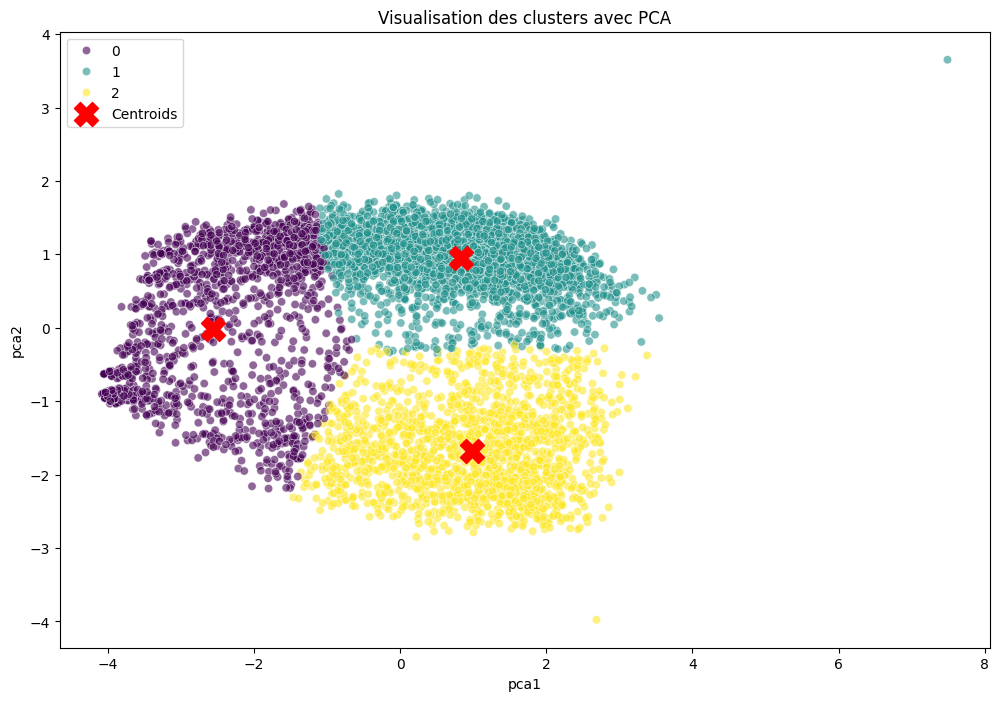

In [4]:
K = 3
clusters, centroids = kmeansTD(data_for_clustering.values, K)

# Ajouter les clusters aux données
data['cluster'] = clusters

# Appliquer la PCA pour la réduction de dimensionnalité
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_for_clustering)
data['pca1'] = data_pca[:, 0]
data['pca2'] = data_pca[:, 1]

# Calcul des centroïdes PCA
centroids_pca = pca.transform(centroids)

# Visualisation des clusters avec PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Visualisation des clusters avec PCA")
plt.legend()
plt.show()

In [ ]:
###### Appliquer l'algorithme K-Means pour 5 clusters 

/home/manel/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


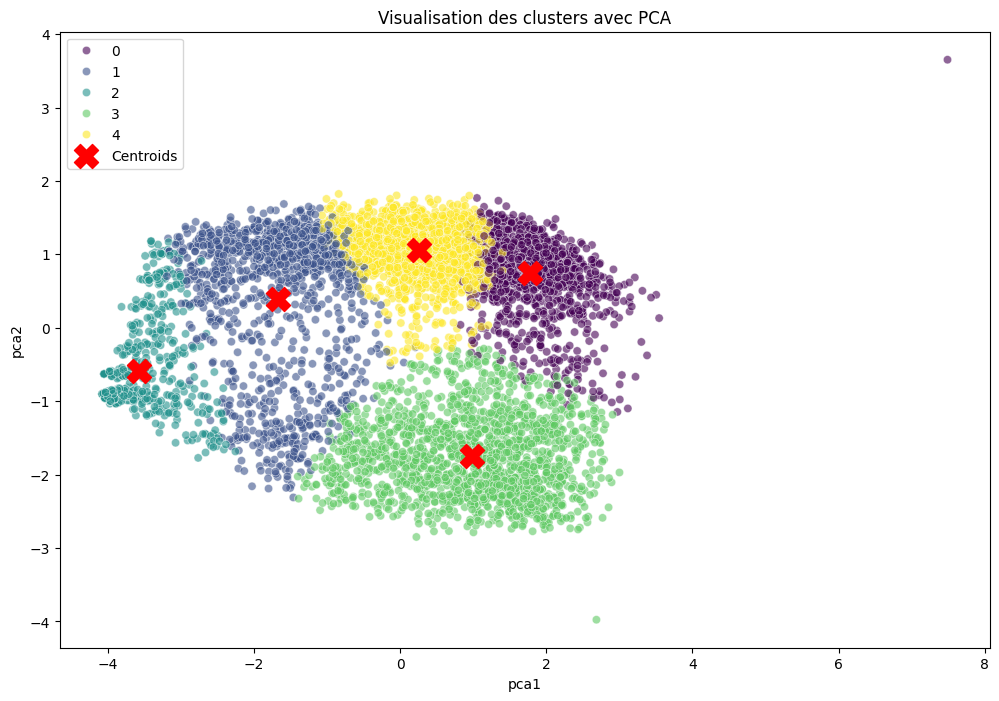

In [11]:
K = 5
clusters, centroids = kmeansTD(data_for_clustering.values, K)

# Ajouter les clusters aux données
data['cluster'] = clusters

# Appliquer la PCA pour la réduction de dimensionnalité
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_for_clustering)
data['pca1'] = data_pca[:, 0]
data['pca2'] = data_pca[:, 1]

# Calcul des centroïdes PCA
centroids_pca = pca.transform(centroids)

# Visualisation des clusters avec PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Visualisation des clusters avec PCA")
plt.legend()
plt.show()


In [ ]:
############### Clustering avec la classe de la bibliotheque sklearn

/home/manel/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


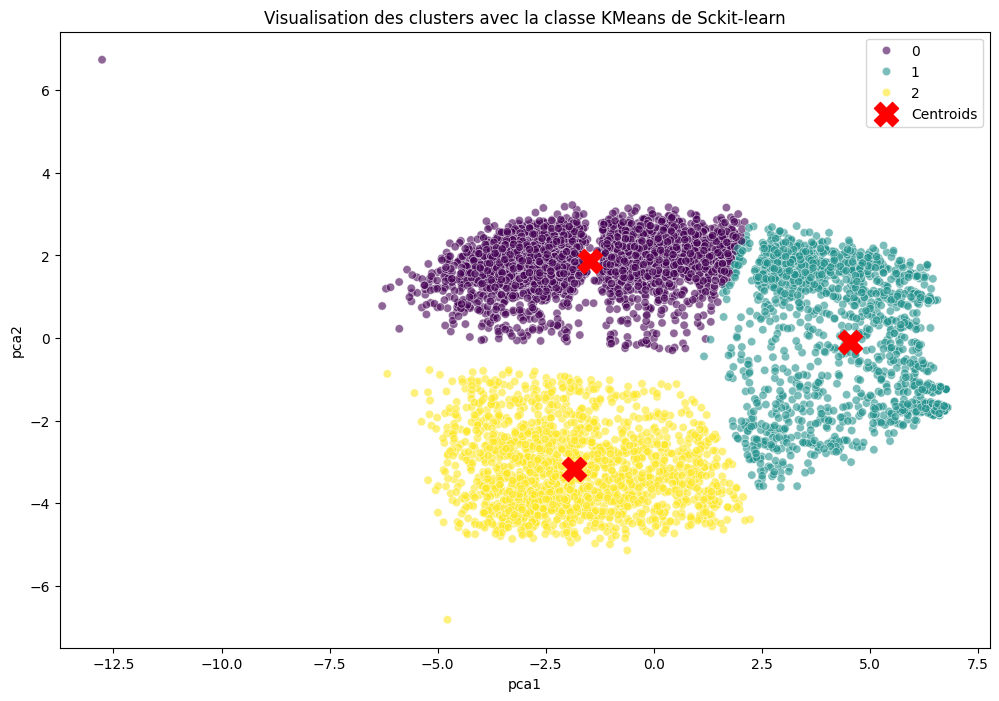

In [9]:
# Application de l'algorithme K-Means pour obtenir 3 clusters 
kmeans = KMeans(n_clusters=3, random_state=42)
data_for_clustering = data.drop(columns=["group", "grand_tot_interests"])
data['cluster'] = kmeans.fit_predict(data_for_clustering)

# Pour chaque cluster, trouver les intérêts principaux
interests_cluster_assignment = {}

for interest in data_for_clustering.columns:
    mean_values = data.groupby('cluster')[interest].mean()
    assigned_cluster = mean_values.idxmax()
    interests_cluster_assignment[interest] = assigned_cluster

# Afficher les intérêts assignés à chaque cluster
clusters_interests = {}
for cluster in range(kmeans.n_clusters):
    clusters_interests[cluster] = [interest for interest, assigned_cluster in interests_cluster_assignment.items() if assigned_cluster == cluster]


# Visualisation des clusters avec PCA et affichage des centroïdes
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_for_clustering)
data['pca1'] = data_pca[:, 0]
data['pca2'] = data_pca[:, 1]

# Calcul des centroïdes PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Visualisation des clusters avec la classe KMeans de Sckit-learn")
plt.legend()
plt.show()


/home/manel/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


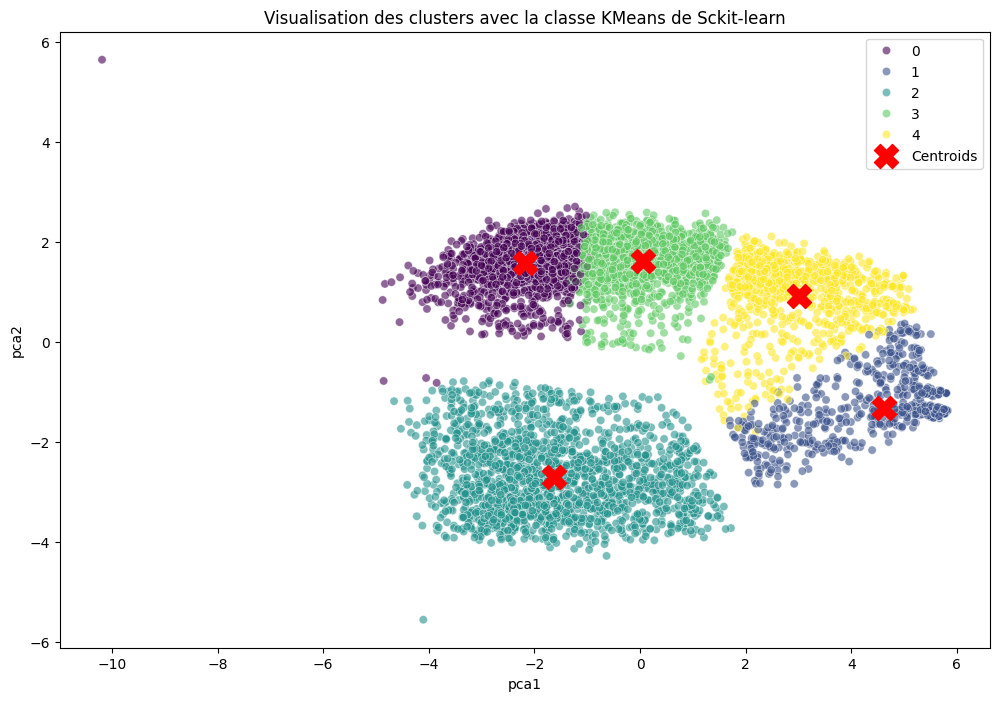

In [8]:
# Application de l'algorithme K-Means pour obtenir 5 clusters 
kmeans = KMeans(n_clusters=5, random_state=42)
data_for_clustering = data.drop(columns=["group", "grand_tot_interests"])
data['cluster'] = kmeans.fit_predict(data_for_clustering)

# Pour chaque cluster, trouver les intérêts principaux
interests_cluster_assignment = {}

# Exclure les colonnes non numériques pour le calcul des moyennes
data_numeric = data_for_clustering.drop(columns=["cluster"])

for interest in data_numeric.columns:
    mean_values = data.groupby('cluster')[interest].mean()
    assigned_cluster = mean_values.idxmax()
    interests_cluster_assignment[interest] = assigned_cluster

# Afficher les intérêts assignés à chaque cluster
clusters_interests = {}
for cluster in range(kmeans.n_clusters):
    clusters_interests[cluster] = [interest for interest, assigned_cluster in interests_cluster_assignment.items() if assigned_cluster == cluster]


# Visualisation des clusters avec PCA et affichage des centroïdes
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_for_clustering)
data['pca1'] = data_pca[:, 0]
data['pca2'] = data_pca[:, 1]

# Calcul des centroïdes PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title("Visualisation des clusters avec la classe KMeans de Sckit-learn")
plt.legend()
plt.show()
